# Facial Expression Classification — FER-2013
## Model 3: Vision Transformer (ViT)

This notebook trains a lightweight Vision Transformer on the FER-2013 dataset.
Run all cells top to bottom.

In [29]:
# Install kaggle if not already installed
!pip install kaggle -q

In [30]:
import os

# Checkpoint directory — works on Colab and local/Kaggle
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory: {CHECKPOINT_DIR}')


Checkpoint directory: checkpoints


In [31]:
# ── Core imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


### Kaggle Authentication with Google Drive

To use Kaggle with Google Colab, you need to provide your `kaggle.json` API token. For this notebook, please upload your `kaggle.json` file into a folder named `Kaggle` within your Google Drive. The expected path will be `/content/drive/My Drive/Kaggle/kaggle.json`.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [34]:
# Please ensure your `kaggle.json` file is placed at `/content/drive/My Drive/Kaggle/kaggle.json` to enable Kaggle dataset download for the FER-2013 task.

In [40]:
# ── Kaggle authentication ──────────────────────────────────────
from google.colab import files
import os

print('Please upload your kaggle.json file...')
uploaded = files.upload()  # This pops up a file picker

if 'kaggle.json' not in uploaded:
    raise FileNotFoundError('kaggle.json not uploaded! Please try again.')

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API key configured successfully!')

Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully!


In [42]:
# ── Download and unzip FER-2013 dataset ───────────────────────
!kaggle datasets download -d msambare/fer2013 --force
!unzip -o fer2013.zip -d fer2013_data
print('Dataset ready.')

Streaming output truncated to the last 5000 lines.
  inflating: fer2013_data/train/sad/Training_65267116.jpg  
  inflating: fer2013_data/train/sad/Training_65275626.jpg  
  inflating: fer2013_data/train/sad/Training_6529266.jpg  
  inflating: fer2013_data/train/sad/Training_65329617.jpg  
  inflating: fer2013_data/train/sad/Training_65338712.jpg  
  inflating: fer2013_data/train/sad/Training_65338797.jpg  
  inflating: fer2013_data/train/sad/Training_65387162.jpg  
  inflating: fer2013_data/train/sad/Training_65404494.jpg  
  inflating: fer2013_data/train/sad/Training_65426218.jpg  
  inflating: fer2013_data/train/sad/Training_65430136.jpg  
  inflating: fer2013_data/train/sad/Training_65437377.jpg  
  inflating: fer2013_data/train/sad/Training_6545735.jpg  
  inflating: fer2013_data/train/sad/Training_65463385.jpg  
  inflating: fer2013_data/train/sad/Training_65473985.jpg  
  inflating: fer2013_data/train/sad/Training_65502829.jpg  
  inflating: fer2013_data/train/sad/Training_655053

In [43]:
# ── Directory paths ────────────────────────────────────────────
train_dir = 'fer2013_data/train'
test_dir  = 'fer2013_data/test'

# Check class folders exist
print('Train classes:', os.listdir(train_dir))
print('Test  classes:', os.listdir(test_dir))

Train classes: ['sad', 'neutral', 'disgust', 'fear', 'angry', 'surprise', 'happy']
Test  classes: ['sad', 'neutral', 'disgust', 'fear', 'angry', 'surprise', 'happy']


## Image Transformations — Rationale

FER-2013 contains 48x48 grayscale face images. The following augmentations were chosen carefully:

| Transformation | Reason |
|---|---|
| **Horizontal flip** | Faces look the same mirrored — valid augmentation |
| **Rotation (±15°)** | Accounts for natural head tilts in real photos |
| **Zoom (±10%)** | Faces appear at different distances from camera |
| **Width/Height shift (±10%)** | Face may not be perfectly centred |
| **Brightness adjustment** | Different lighting conditions in real environments |
| **Rescale 1/255** | Normalises pixel values to [0, 1] range |

**Transformations deliberately avoided:**
- Vertical flip — upside-down faces are not realistic
- Heavy shear/distortion — would destroy facial expression features
- Channel shift — not applicable for grayscale images

**Note:** ResNet50V2 requires RGB input (3 channels) and minimum 32x32 size.
We resize images to 224x224 and convert grayscale to RGB by repeating channels.

In [44]:
# ── Configuration ──────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # ResNet50V2 needs at least 32x32; 224x224 balances speed & detail
BATCH_SIZE  = 32
NUM_CLASSES = 7
EPOCHS_FROZEN   = 15    # Train only the top layers first
EPOCHS_UNFROZEN = 35    # Fine-tune the whole network

In [45]:
# ── Image Augmentation for Training Data ──────────────────────
# These transformations are ONLY applied to training data
# to artificially increase dataset diversity and reduce overfitting

train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalise pixels to [0, 1]
    validation_split=0.2,       # 80% train, 20% validation

    # ── Geometric transformations ──
    horizontal_flip=True,       # Mirror faces horizontally
    rotation_range=15,          # Rotate up to 15 degrees either way
    zoom_range=0.10,            # Zoom in/out by up to 10%
    width_shift_range=0.10,     # Shift left/right by up to 10%
    height_shift_range=0.10,    # Shift up/down by up to 10%

    # ── Photometric transformations ──
    brightness_range=[0.8, 1.2], # Vary brightness to simulate lighting changes

    fill_mode='nearest'          # Fill empty pixels after rotation/shift
)

# Validation and test data: ONLY rescale, NO augmentation
# (we want a fair, unmodified evaluation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print('Augmentation pipeline configured.')

Augmentation pipeline configured.


In [46]:
# ── Data Loaders ───────────────────────────────────────────────
# ResNet50V2 requires colour_mode='rgb' (3 channels)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',           # Convert grayscale to 3-channel RGB
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                # Keep order for confusion matrix
)

class_names = list(train_data.class_indices.keys())
print('Classes:', class_names)
print('Training samples:  ', train_data.samples)
print('Validation samples:', val_data.samples)
print('Test samples:      ', test_data.samples)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples:   22968
Validation samples: 5741
Test samples:       7178


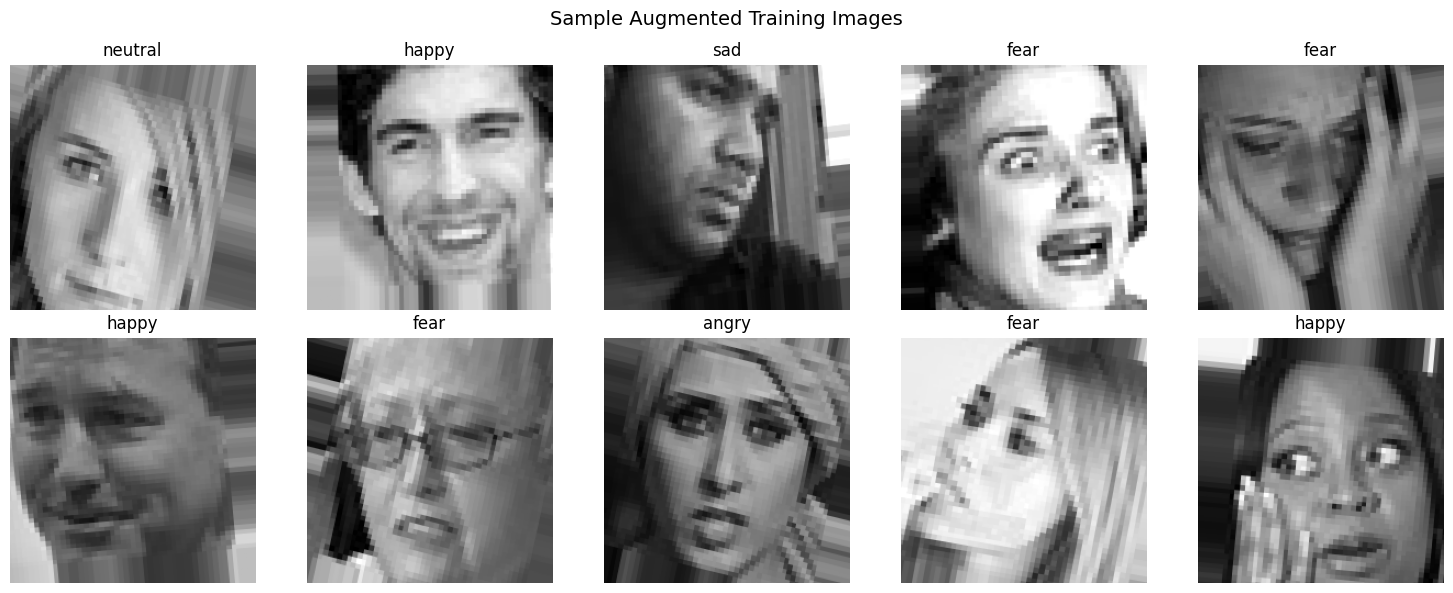

In [47]:
# ── Visualise augmented training samples ──────────────────────
# This confirms augmentation is working correctly

sample_images, sample_labels = next(train_data)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

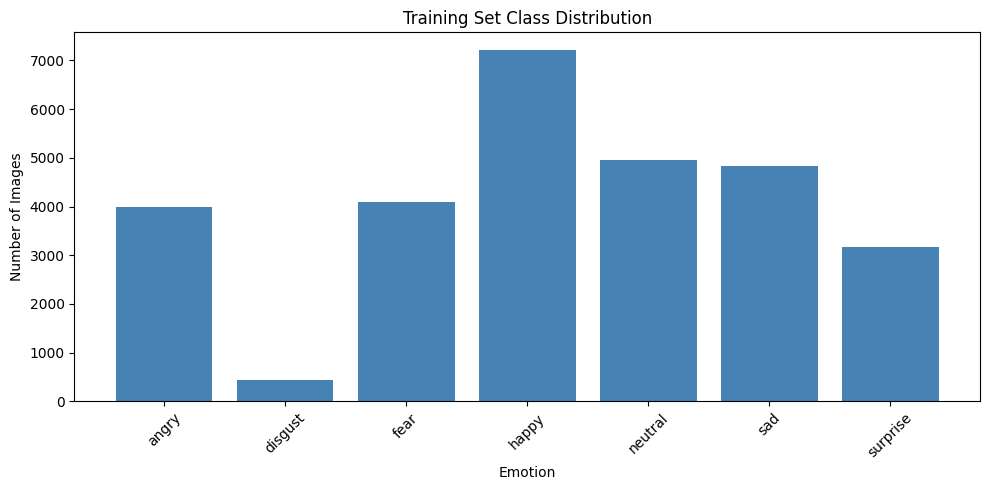

Class distribution: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


In [48]:
# ── Visualise class distribution ──────────────────────────────
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Training Set Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Class distribution:', class_counts)

In [49]:
# ── Learning curve helper ────────────────────────────────────
import matplotlib.pyplot as plt

def plot_learning_curves(history1, history2, title_prefix='Model'):
    acc      = history1.history['accuracy']     + history2.history['accuracy']
    val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss     = history1.history['loss']         + history2.history['loss']
    val_loss = history1.history['val_loss']     + history2.history['val_loss']
    stage_boundary = len(history1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title_prefix} — Learning Curves', fontsize=14)
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linestyle='--')
    ax1.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linestyle='--')
    ax2.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [50]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))


In [51]:

from tensorflow.keras import layers

def build_vit_model(input_shape=(224,224,3), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Patch embedding
    patches = layers.Conv2D(64, kernel_size=16, strides=16)(inputs)
    patches = layers.Reshape((-1, 64))(patches)

    # Transformer block
    x = patches
    for _ in range(4):
        x1 = layers.LayerNormalization()(x)
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x1, x1)
        x2 = layers.Add()([attention, x])

        x3 = layers.LayerNormalization()(x2)
        mlp = layers.Dense(128, activation='relu')(x3)
        mlp = layers.Dense(64)(mlp)

        x = layers.Add()([mlp, x2])

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="ViT_FER")

    return model


In [52]:
VIT_model = build_vit_model(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

VIT_model.summary()

Model: "ViT_FER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,216 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 391,239 (1.49 MB)

 Trainable params: 391,239 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
from tensorflow.keras.callbacks import ModelCheckpoint

VIT_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Adjusted learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to prevent overfitting and reduce learning rate on plateau
vit_callbacks_stage1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5, # Adjusted factor
        patience=5, # Adjusted patience
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'vit_stage1_{epoch:02d}-{val_loss:.2f}.keras'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

print('Stage 1: Training classification head (base frozen)...')
history_vit_stage1 = VIT_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FROZEN,
    callbacks=vit_callbacks_stage1,
    verbose=1,
    class_weight=class_weights # Added class_weights
)

print('Stage 1 complete.')

Stage 1: Training classification head (base frozen)...
Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1462 - loss: 2.0131
Epoch 1: val_loss improved from None to 1.91507, saving model to checkpoints/vit_stage1_01-1.92.keras

Epoch 1: finished saving model to checkpoints/vit_stage1_01-1.92.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 969s 1s/step - accuracy: 0.1467 - loss: 1.9835 - val_accuracy: 0.1582 - val_loss: 1.9151 - learning_rate: 1.0000e-04
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1630 - loss: 1.9195
Epoch 2: val_loss did not improve from 1.91507
718/718 ━━━━━━━━━━━━━━━━━━━━ 961s 1s/step - accuracy: 0.1627 - loss: 1.9422 - val_accuracy: 0.0916 - val_loss: 1.9859 - learning_rate: 1.0000e-04
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1652 - loss: 1.9660
Epoch 3: val_loss did not improve from 1.91507
718/718 ━━━━━━━━━━━━━━━━━━━━ 973s 1s/step - accuracy: 0.1688 - loss: 1.9368 - val_accuracy: 0.1789 - val_loss: 1.9330 - learning_r

In [54]:
print('ViT Stage 1 weights saved. Proceeding to Stage 2 fine-tuning...')


ViT Stage 1 weights saved. Proceeding to Stage 2 fine-tuning...


In [55]:
# Save model after Stage 1
stage1_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    'vit_stage1.weights.h5'
)

VIT_model.save_weights(stage1_checkpoint_path)

print(f'Stage 1 weights saved to: {stage1_checkpoint_path}')

Stage 1 weights saved to: checkpoints/vit_stage1.weights.h5


In [56]:
# Check if VIT_model is defined. If not, re-instantiate it.
# This will reset the model and lose any training from Stage 1.
# It is recommended to run cell 2ODiz30ZPelY and SYOiO25YP2xc before this cell.
from tensorflow.keras.callbacks import ModelCheckpoint

if 'VIT_model' not in locals() and 'VIT_model' not in globals():
    VIT_model = build_vit_model(
        input_shape=(224, 224, 3),
        num_classes=NUM_CLASSES
    )
    print("Warning: VIT_model was not defined. Re-instantiated model, losing Stage 1 training progress. Please ensure previous cells (2ODiz30ZPelY and SYOiO25YP2xc) are run if you wish to continue training from Stage 1.")

print('Stage 2: Further training VIT model with lower learning rate...')

VIT_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # Very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vit_callbacks_stage2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5, # Adjusted factor
        patience=3, # Adjusted patience
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'vit_stage2_{epoch:02d}-{val_loss:.2f}.keras'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

history_stage2_vit = VIT_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_UNFROZEN, # Use EPOCHS_UNFROZEN for continued training
    callbacks=vit_callbacks_stage2, # Reuse callbacks_stage2
    verbose=1,
    class_weight=class_weights # Added class_weights
)

print('Stage 2 complete for ViT model.')

Stage 2: Further training VIT model with lower learning rate...
Epoch 1/35
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1677 - loss: 1.9097
Epoch 1: val_loss improved from None to 1.93261, saving model to checkpoints/vit_stage2_01-1.93.keras

Epoch 1: finished saving model to checkpoints/vit_stage2_01-1.93.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 973s 1s/step - accuracy: 0.1603 - loss: 1.9324 - val_accuracy: 0.1561 - val_loss: 1.9326 - learning_rate: 1.0000e-05
Epoch 2/35
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1564 - loss: 1.9516
Epoch 2: val_loss improved from 1.93261 to 1.91533, saving model to checkpoints/vit_stage2_02-1.92.keras

Epoch 2: finished saving model to checkpoints/vit_stage2_02-1.92.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 970s 1s/step - accuracy: 0.1642 - loss: 1.9295 - val_accuracy: 0.1951 - val_loss: 1.9153 - learning_rate: 1.0000e-05
Epoch 3/35
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1777 - loss: 1.9351
Epoch 3: val_loss did not improve from

## Evaluate ViT Model on Test Set

In [58]:
print('Evaluating ViT model on test set...')
test_loss_vit, test_acc_vit = VIT_model.evaluate(test_data, verbose=1)
print(f'\nTest Loss (ViT):     {test_loss_vit:.4f}')
print(f'Test Accuracy (ViT): {test_acc_vit:.4f} ({test_acc_vit*100:.2f}%)')

Evaluating ViT model on test set...
225/225 ━━━━━━━━━━━━━━━━━━━━ 72s 320ms/step - accuracy: 0.2072 - loss: 1.9086

Test Loss (ViT):     1.9086
Test Accuracy (ViT): 0.2072 (20.72%)


## ViT Model Predictions and Classification Report

In [59]:
# Reset test generator to ensure correct order
test_data.reset()

# Generate predictions for ViT model
y_pred_probs_vit   = VIT_model.predict(test_data, verbose=1)
y_pred_classes_vit = np.argmax(y_pred_probs_vit, axis=1)
y_true_vit         = test_data.classes # True labels are the same

print('\nClassification Report (ViT):')
print(classification_report(
    y_true_vit,
    y_pred_classes_vit,
    target_names=class_names
))

225/225 ━━━━━━━━━━━━━━━━━━━━ 73s 324ms/step

Classification Report (ViT):
              precision    recall  f1-score   support

       angry       1.00      0.00      0.00       958
     disgust       0.00      0.00      0.00       111
        fear       0.00      0.00      0.00      1024
       happy       0.25      0.20      0.23      1774
     neutral       0.18      0.21      0.20      1233
         sad       0.23      0.31      0.26      1247
    surprise       0.18      0.58      0.27       831

    accuracy                           0.21      7178
   macro avg       0.26      0.19      0.14      7178
weighted avg       0.29      0.21      0.17      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ViT Model Confusion Matrix

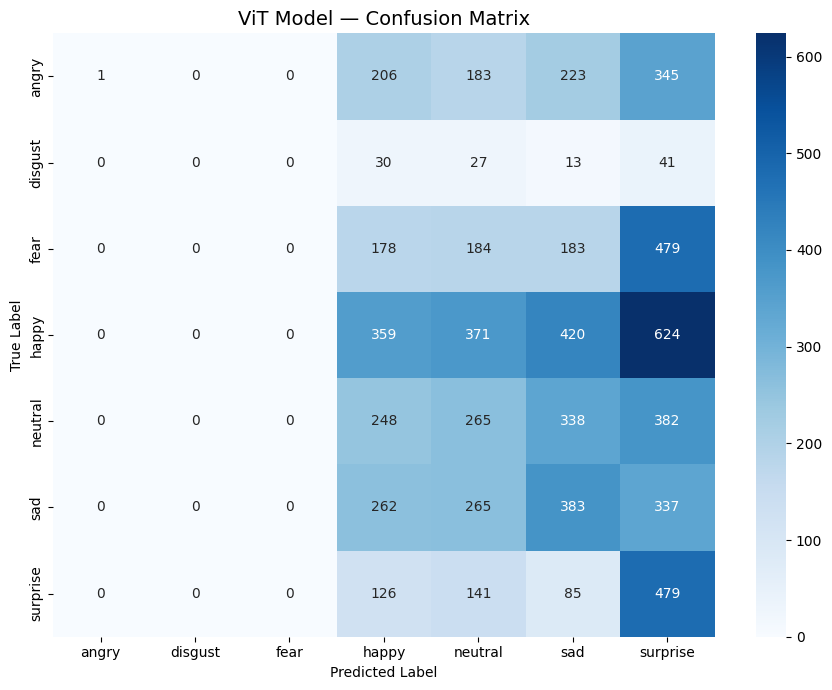

Confusion matrix for ViT model displayed.


In [60]:
cm_vit = confusion_matrix(y_true_vit, y_pred_classes_vit)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_vit,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ViT Model — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('Confusion matrix for ViT model displayed.')

## ViT Model Learning Curves

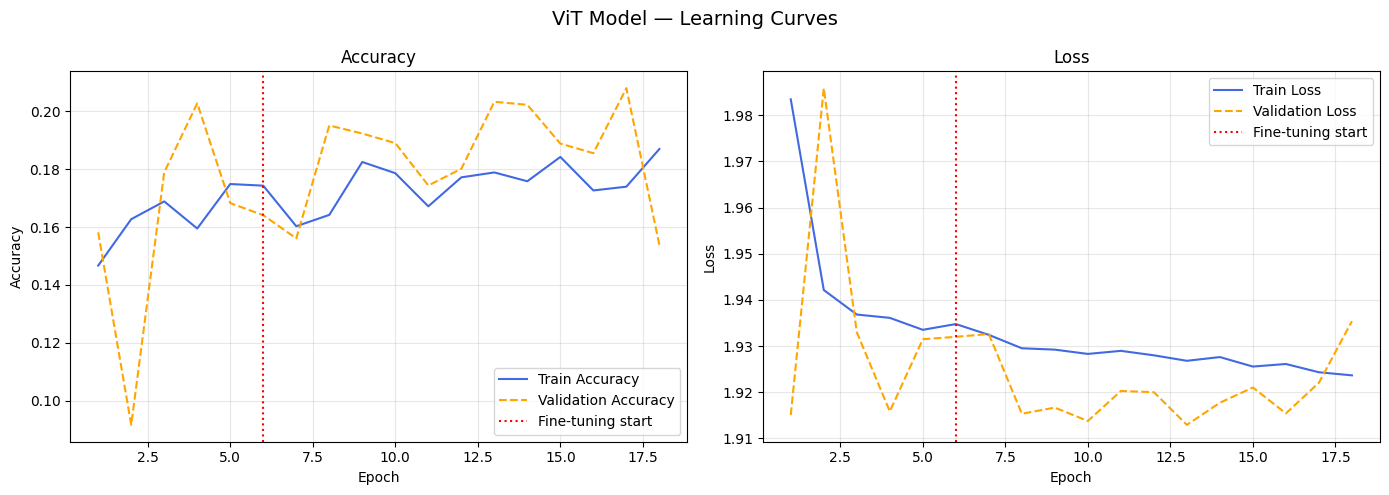

In [61]:
plot_learning_curves(history_vit_stage1, history_stage2_vit, 'ViT Model')

## Save the ViT Model

In [62]:
if 'VIT_model' in locals() or 'VIT_model' in globals():
    VIT_model.save('vit_fer2013.keras')
    print('ViT Model saved as vit_fer2013.keras')
else:
    print('Error: VIT_model is not defined. Please ensure the model has been built and trained before attempting to save it.')

ViT Model saved as vit_fer2013.keras


## Example: Training a Simple Linear Regression Model

Generating synthetic linear data...


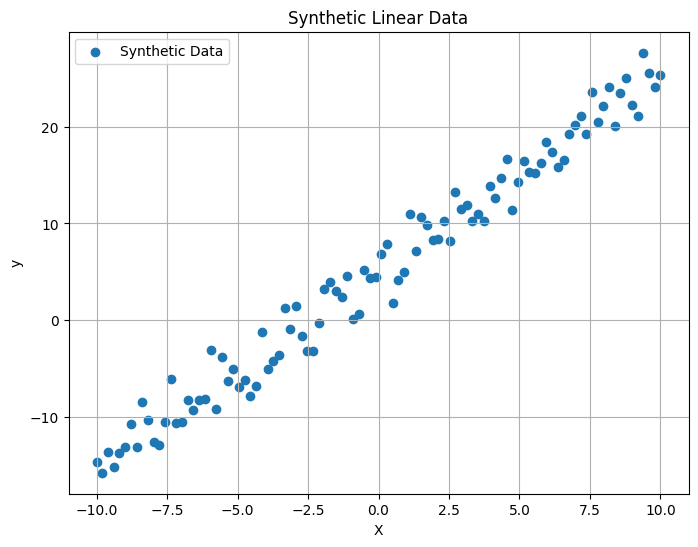

Synthetic data generated.


In [63]:
print('Generating synthetic linear data...')

# Generate some synthetic data for a simple linear regression
X = np.linspace(-10, 10, 100)
y = 2 * X + 5 + np.random.normal(0, 2, 100) # y = 2x + 5 + noise

# Reshape X for Keras input
X = X.reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Synthetic Data')
plt.title('Synthetic Linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print('Synthetic data generated.')

### Define a Simple Keras Model

In [64]:
print('Defining a simple Keras model...')

# Define a simple linear regression model using Keras
simple_model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

simple_model.summary()

print('Model defined.')

Defining a simple Keras model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Model defined.


### Compile and Train the Model

Compiling and training the simple model...
Model training complete.


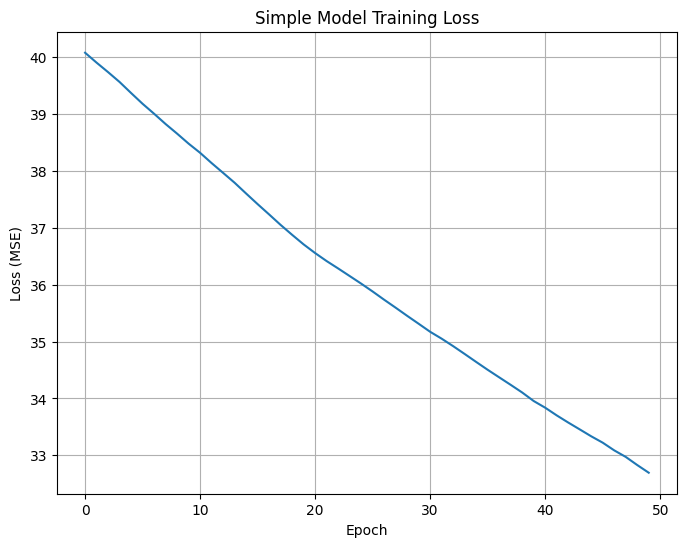

In [65]:
print('Compiling and training the simple model...')

# Compile the model
simple_model.compile(optimizer='adam', loss='mse') # Mean Squared Error for regression

# Train the model
history_simple = simple_model.fit(X, y, epochs=50, verbose=0)

print('Model training complete.')

# Plot training loss
plt.figure(figsize=(8, 6))
plt.plot(history_simple.history['loss'])
plt.title('Simple Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

### Make Predictions and Visualize

Making predictions and visualizing results...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


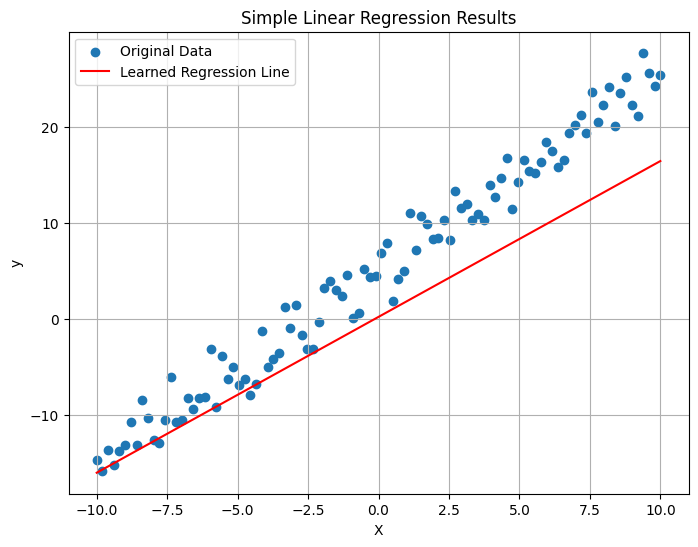

Prediction and visualization complete.


In [66]:
print('Making predictions and visualizing results...')

# Make predictions with the trained model
y_pred = simple_model.predict(X)

# Plot the original data and the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_pred, color='red', label='Learned Regression Line')
plt.title('Simple Linear Regression Results')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print('Prediction and visualization complete.')